In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import struct

sns.set_theme()

In [4]:
data_dir = "/home/patricka/Projects/DataScienceAndMachineLearning/Data/"

train_labels_path = data_dir + "MNIST-Dataset/train-labels.idx1-ubyte"
train_images_path = data_dir + "MNIST-Dataset/train-images.idx3-ubyte"
test_labels_path = data_dir + "MNIST-Dataset/t10k-labels.idx1-ubyte"
test_images_path = data_dir + "MNIST-Dataset/t10k-images.idx3-ubyte"

def read_labels(labels_path):
    with open(labels_path, "rb") as file:
        magic, size = struct.unpack(">II", file.read(8))
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels

def read_images(images_path):
    with open(images_path, "rb") as file:
        magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
        image_data = np.frombuffer(file.read(), dtype=np.uint8)
        final_image_data = np.empty((size, rows, cols), dtype=np.uint8)
        for i in range(size):
            img = image_data[i*rows*cols:(i+1)*rows*cols].reshape(rows, cols)
            final_image_data[i, :, :] = img
        return final_image_data
train_labels = read_labels(train_labels_path)
train_images = read_images(train_images_path)
test_labels = read_labels(test_labels_path)
test_images = read_images(test_images_path)

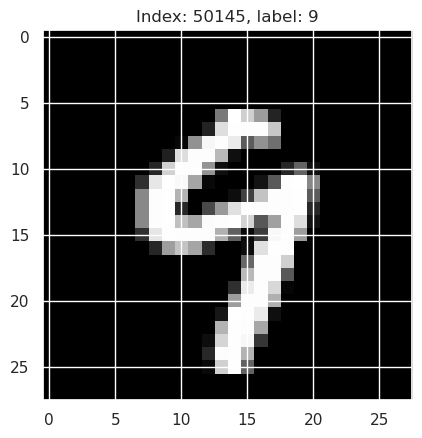

In [5]:
def show_image(images, labels, index):
    plt.imshow(images[index, :, :], cmap=plt.cm.gray)
    plt.title(f"Index: {index}, label: {labels[index]}")
    plt.show()

show_image(train_images, train_labels, 50145)

In [6]:
X = train_images / 255.0
y = np.zeros((len(train_labels), 10))
for i in range(len(train_labels)):
    label = train_labels[i]
    y[i, label] = 1.0

In [11]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def derivative_sigmoid(x):
    return sigmoid(x) * (1.0-sigmoid(x))

In [16]:
class MultilayerPerceptron():
    def __init__(self, _layer_counts, _activation_function, _activation_function_derivative):
        # layer_counts is a list of the number of neurons to place in each hidden layer. The length
        # of layer_counts indicates how many hidden layers there are.
        self.layer_counts = _layer_counts
        self.activation_function = _activation_function
        self.activation_function_derivative = _activation_function_derivative

    def train(self, X, y, possible_outputs, eta = 0.1, epochs = 1000):
        # first extract dimensional information
        self.dim = X.shape[0]
        self.rows, self.cols = X.shape[1], X.shape[2]
        self.weights = [] # list of np matrices
        self.bias = [] # list of np arrays

        # first layer neurons are just the values of the image, no neurons necessary

        all_layer_counts = [self.rows*self.cols]
        all_layer_counts.extend(self.layer_counts)
        all_layer_counts.append(possible_outputs)
        
        activations = []
        z_vals = []
        error_vals = []

        self.n = len(all_layer_counts)
        self.batch_size = 100 # set batch size to be a divisor of the training data length

        for i in range(self.n-1):
            # create neuron layer
            num_weights_per_neuron = all_layer_counts[i]
            num_neurons = all_layer_counts[i+1]
            self.weights.append(np.random.randn(num_weights_per_neuron, num_neurons)*np.sqrt(1/num_weights_per_neuron))
            self.bias.append(np.random.randn(num_neurons, 1)*1/num_weights_per_neuron)
        for i in range(self.n):
            z_vals.append(np.empty((self.batch_size, all_layer_counts[i])))
            activations.append(np.empty((self.batch_size, all_layer_counts[i])))
            error_vals.append(np.empty((self.batch_size, all_layer_counts[i])))
        
        # what to code here?
        # first off: feedforward
        # then: backprop for a sample of the dataset
        current_loc = 0
        
        i = 0
        while i < epochs:
            X_batch = X[current_loc:current_loc+self.batch_size, :, :].reshape(self.batch_size, -1) # batch size by rows*cols matrix
            y_batch = y[current_loc:current_loc+self.batch_size, :] # batch size by possible_outputs matrix
            current_loc += self.batch_size
            if current_loc >= self.dim:
                current_loc = 0
            activations[0] = X_batch
            # contains a_L
            for j in range(self.n-1):
                z_val = np.dot(self.weights[j].T, activations[j].T).T + self.bias[j].T
                activation = self.activation_function(z_val)
                z_vals[j+1] = z_val
                activations[j+1] = activation
            grad_C = 1/self.batch_size * (activations[-1] - y_batch) # dimension batch_size by possible_outputs
            z_deriv = self.activation_function_derivative(z_vals[-1])
            error_vals[-1] = grad_C * z_deriv # needs to be batch_size by possible_outputs
            for j in range(self.n-2, 0, -1):
                error_leftside = np.dot(self.weights[j], error_vals[j+1].T).T
                error_val = error_leftside * self.activation_function_derivative(z_vals[j])
                error_vals[j] = error_val
            for j in range(self.n-1, 0, -1):
                self.weights[j-1] = self.weights[j-1] - eta*np.dot(error_vals[j].T, (activations[j-1])).T
                
                # print(np.shape(self.bias[j-1]))
                # print(np.shape(eta*np.sum(error_vals[j].T, axis=1, keepdims=True)))
                self.bias[j-1] = self.bias[j-1] - eta*np.sum(error_vals[j].T, axis=1, keepdims=True)
                # print(np.shape(self.bias[j-1]))
            # print(self.cost(y_batch, activations[n-1]))
            i += 1
            if i % 100 == 0:
                print(self.cost(y_batch, activations[-1]))
                print(activations[-1][0])
                print(y_batch[0])
                print("-----")
        # how to store weights? should probably just store neuron objects

    def cost(self, y, y_hats):
        return 1/(2*self.batch_size) * np.sum((y-y_hats)**2, axis=0)

    def feed_forward(self, X):
        activation = X
        for j in range(self.n-1):
            z_val = np.dot(self.weights[j].T, activation.T).T + self.bias[j].T
            activation = self.activation_function(z_val)
        return activation

    # once we have batch set: compute the feed forward to get the diffs

In [17]:
nn = MultilayerPerceptron([16, 16], sigmoid, derivative_sigmoid)
errors = nn.train(X, y, 10, eta = 0.5, epochs=10000)

[0.05244517 0.05222654 0.03712256 0.04479068 0.03678391 0.02857722
 0.04900932 0.04872219 0.06136963 0.0368919 ]
[0.10384464 0.11001187 0.09882422 0.10504121 0.0906744  0.08793809
 0.10085136 0.10333607 0.09187825 0.09531253]
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
-----
[0.05175638 0.04416569 0.03293375 0.04091636 0.04887614 0.05314443
 0.05284223 0.03265793 0.04111275 0.04888939]
[0.11969043 0.11188632 0.09758552 0.10757553 0.08887805 0.08546632
 0.10024698 0.09597366 0.10094455 0.1020015 ]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
-----
[0.04025036 0.05907937 0.03290027 0.0327719  0.0410537  0.03280262
 0.0448046  0.06382121 0.03695678 0.06054533]
[0.10782741 0.12539784 0.10334805 0.10127939 0.10486109 0.09837714
 0.10449757 0.11199817 0.09691137 0.1060201 ]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
-----
[0.03885205 0.05038903 0.04462229 0.04437198 0.03305992 0.07753936
 0.0253142  0.03279258 0.04905714 0.04850411]
[0.12676143 0.11167124 0.10951623 0.11238146 0.09355647 0.08933358
 0.10991477 0.10016616 0.097

In [22]:
# now test! prep test data
X_test = test_images / 255.0
y_test = np.zeros((len(test_labels), 10))
for i in range(len(test_labels)):
    label = test_labels[i]
    y_test[i, label] = 1.0
# for i in range(nn.n):
#     print(np.shape(nn.bias[i]))
y_hat_test = nn.feed_forward(X_test.reshape(10000, -1))
y_argmax = np.argmax(y, axis=1)
print(y_argmax)
results = sum(1 if y_data == y_hat_data else 0 for (y_data, y_hat_data) in zip(np.argmax(y_test, axis=1), np.argmax(y_hat_test, axis=1)))
print(results / 10000.0)

[5 0 4 ... 5 6 8]
0.9296
